<a href="https://colab.research.google.com/github/tgiouva/ERGASIA4MNIST/blob/main/ERGASIA4MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

# Setting Environment Seeds

Seeds enable the reproduction of the experiments.

In [ ]:
random.seed(0)
np.random.seed(seed=0)
tf.random.set_seed(seed=0)

# Load MNIST Dataset using Tensorflow

In [ ]:
(x_train, y_train), (x_test, y_test ) = tf.keras.datasets.mnist.load_data()
x_train.shape, y_train.shape, x_test.shape, y_test.shape

print(
    f'Training Size - Inputs:{x_train.shape}, Targets:{y_train.shape}'
    f'\nTest Size - Inputs:{x_test.shape}, Targets:{y_test.shape}'
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Size - Inputs:(60000, 28, 28), Targets:(60000,)
Test Size - Inputs:(10000, 28, 28), Targets:(10000,)


# Displaying Random Digits

In [ ]:
rows = 5
digits_per_row = 5

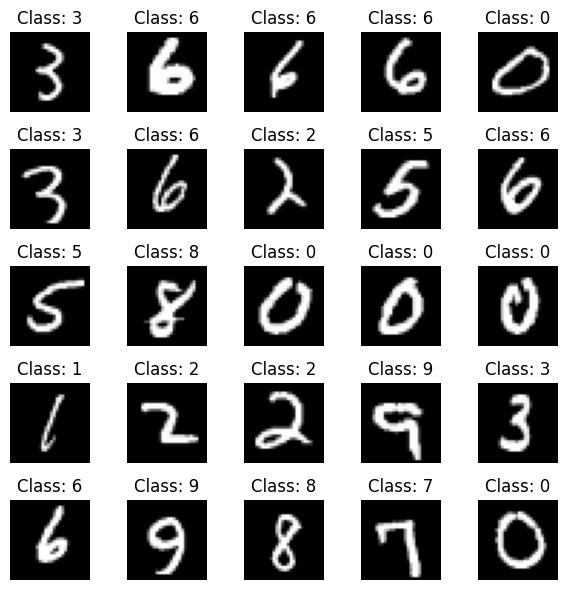

In [ ]:
fig, axes = plt.subplots(nrows=rows, ncols=digits_per_row, figsize=(6, 6))
axes = axes.flatten()

# Selecting random ids from 0 to 60000
total_digits = rows*digits_per_row
random_ids= np.random.choice(x_train.shape[0], total_digits, replace=False)

# Plotting the selected digits.
for i, ax in enumerate(axes):
    idx = random_ids[i]
    ax.imshow(x_train[idx], cmap='gray')
    ax.set_title(f'Class: {y_train[idx]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Preprocessing Inputs


*   Deep Neural Networks require vectors are inputs. Since the digits are 28x28
*   One-hot Encoding is required for targets, since we use 10 classes. (e.g. 0 will be classified as 0 0 0 0 0 0 0 0 0 1, one will be classified as 0 0 0 0 0 0 0 0 1 0, etc.

grayscale images, they should be converted to vectors of 784 size.

In [ ]:
x_train = x_train.reshape((60000, 784))
y_train = tf.one_hot(y_train, depth=10)
x_test = x_test.reshape((10000, 784))
y_test = tf.one_hot(y_test, depth=10)

print(
    f'Training Size - Inputs:{x_train.shape}, Targets:{y_train.shape}'
    f'\nTest Size - Inputs:{x_test.shape}, Targets:{y_test.shape}'
)

Training Size - Inputs:(60000, 784), Targets:(60000, 10)
Test Size - Inputs:(10000, 784), Targets:(10000, 10)


# Construct Deep Neural Network





*   Input: 784 Features
*   Hiddens: 2 Hiddens of 256 units, which pass through tanh activation.
*   Output: 10 probabilities (1 for each class). Softmax activation is required to convert the network's outputs into probabilities.



In [ ]:
activation = 'tanh'
loss = 'categorical_crossentropy' # Do not change this loss function.
metrics = ['accuracy']
learning_rate = 0.001
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate) # Do not change this optimizer.
epochs = 10

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,), name='input'),
    tf.keras.layers.Dense(units=256, activation=activation, name='hidden-1'),
    tf.keras.layers.Dense(units=256, activation=activation, name='hidden-2'),
    tf.keras.layers.Dense(units=10, activation='softmax', name='outputs') # Do not change this activation function.
])
model.summary(expand_nested=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden-1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden-2 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
history = model.fit(
    x=x_train,
    y=y_train,
    epochs=epochs,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7402 - loss: 0.9154 - val_accuracy: 0.8685 - val_loss: 0.5154
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8781 - loss: 0.4513 - val_accuracy: 0.8988 - val_loss: 0.3783
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8970 - loss: 0.3647 - val_accuracy: 0.9080 - val_loss: 0.3277
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9103 - loss: 0.3173 - val_accuracy: 0.9166 - val_loss: 0.2983
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9173 - loss: 0.2873 - val_accuracy: 0.9236 - val_loss: 0.2733
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9238 - loss: 0.2675 - val_accuracy: 0.9259 - val_loss: 0.2606
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9286 - loss: 0.2495 - val_accuracy: 0.9314 - val_loss: 0.2453
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9319 - loss: 0.2363 - 

# Display Loss and Accuracy per Training Epoch

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

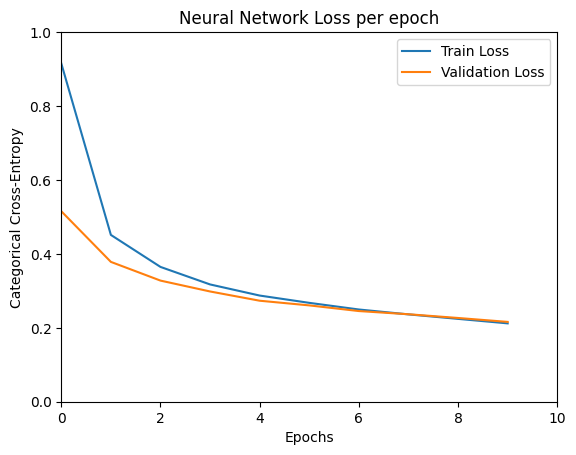

In [ ]:
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Neural Network Loss per epoch')
plt.ylabel('Categorical Cross-Entropy')
plt.xlabel('Epochs')
plt.xlim(0, epochs)
plt.ylim(0, 1)
plt.legend()
plt.show()

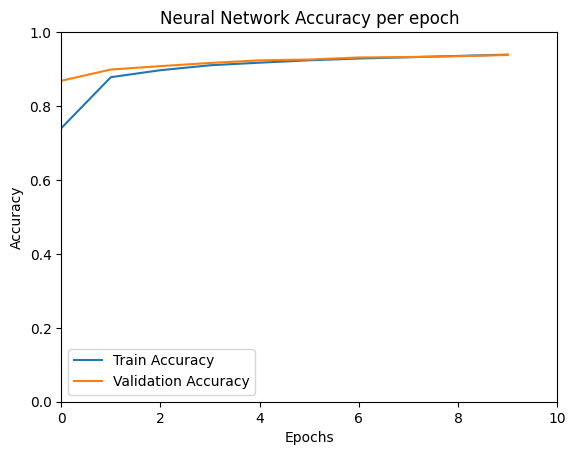

In [ ]:
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Neural Network Accuracy per epoch')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.xlim(0, epochs)
plt.ylim(0, 1)
plt.legend()
plt.show()

# --- TODOs ---

## 1. Hyperparameter Tuning: Try adjusting number of hidden layers, hidden units, activation function, learning rate, number of epochs, etc.


In [ ]:
configs=[
    {
        'name':'Baseline (αρχικό)',
        'layers':[256,256],
        'activation':'tanh',
        'lr': 0.001,
        'epochs': 10,
    },
    {
        'name':'relu αντί tanh',
        'layers':[256,256],

        'activation': 'relu',
        'lr':0.001,
        'epochs':10,
    },
    {
        'name':'3 layers με relu',
        'layers': [256,256,256],
        'activation':'relu',
        'lr': 0.001,
        'epochs':10,
    },





    {
        'name':'LR=0.01 με relu',
        'layers':[256,256],
        'activation':'relu',
        'lr':0.01,
        'epochs':10,
    },
    {

        'name':'Μικρό δίκτυο 128x128',
        'layers': [128, 128],
        'activation':'relu',
        'lr':0.001,
        'epochs':10,
    },
    {
        'name':'Μεγάλο 512x256-20 εποχές',
        'layers': [512,256],
        'activation':'relu',
        'lr':0.01,
        'epochs':20,
    },
]

results=[]
for cfg in configs:
    print(f"Δοκιμή:{cfg['name']}")
    layers_list=[tf.keras.layers.Input(shape=(784,),name='input')]
    for i,units in enumerate(cfg['layers']):
      layers_list.append(tf.keras.layers.Dense(units=units,activation=cfg['activation'],name=f'hidden-{i+1}'))
    layers_list.append(tf.keras.layers.Dense(units=10,activation='softmax',name='outputs'))
    m=tf.keras.Sequential(layers_list)

    opt=tf.keras.optimizers.SGD(learning_rate=cfg['lr'])
    m.compile(optimizer=opt,loss='categorical_crossentropy',metrics=['accuracy'])

    hist=m.fit(
        x=x_train,
        y=y_train,
        epochs=cfg['epochs'],
        validation_data=(x_test,y_test),
        verbose=0
    )
    tr_acc=hist.history['accuracy'][-1]
    val_acc=hist.history['val_accuracy'][-1]
    print(f"Train Accuracy: {tr_acc*100:.2f}% | Val Accuracy:{val_acc*100:.2f}%")

    results.append({
        'Συνδυασμός':cfg['name'],


        'Layers': str(cfg['layers']),
        'Activation':cfg['activation'],
        'Learning Rate': cfg['lr'],
        'Epochs':cfg['epochs'],
        'Train Acc':f"{tr_acc*100:.2f}%",
        'Val Acc':f"{val_acc*100:.2f}%",
    })

df_results = pd.DataFrame(results)
print("\n\nΠίνακας Αποτελεσμάτων")
print(df_results.to_string(index=False))

Δοκιμή:Baseline (αρχικό)
Train Accuracy: 93.55% | Val Accuracy:93.15%
Δοκιμή:relu αντί tanh
Train Accuracy: 99.80% | Val Accuracy:95.04%
Δοκιμή:3 layers με relu
Train Accuracy: 99.87% | Val Accuracy:95.72%
Δοκιμή:LR=0.01 με relu
Train Accuracy: 9.87% | Val Accuracy:9.80%
Δοκιμή:Μικρό δίκτυο 128x128
Train Accuracy: 97.39% | Val Accuracy:94.75%
Δοκιμή:Μεγάλο 512x256-20 εποχές
Train Accuracy: 9.87% | Val Accuracy:9.80%


Πίνακας Αποτελεσμάτων
              Συνδυασμός          Layers Activation  Learning Rate  Epochs Train Acc Val Acc
       Baseline (αρχικό)      [256, 256]       tanh          0.001      10    93.55%  93.15%
          relu αντί tanh      [256, 256]       relu          0.001      10    99.80%  95.04%
        3 layers με relu [256, 256, 256]       relu          0.001      10    99.87%  95.72%
         LR=0.01 με relu      [256, 256]       relu          0.010      10     9.87%   9.80%
    Μικρό δίκτυο 128x128      [128, 128]       relu          0.001      10    97.39%  94.75

In [ ]:
extra_configs=[
    {
        'name':'relu 256x256-20 εποχές',
        'layers': [256,256],
        'activation':'relu',
        'lr':0.001,
        'epochs':20,
    },
    {
        'name':'relu 512x512-20 εποχές',
        'layers': [512,512],
        'activation':'relu',
        'lr':0.001,
        'epochs':20,
    },
]

for cfg in extra_configs:



    print(f"Δοκιμή:{cfg['name']}")

    layers_list=[tf.keras.layers.Input(shape=(784,),name='input')]
    for i, units in enumerate(cfg['layers']):
        layers_list.append(tf.keras.layers.Dense(   units=units,activation=cfg['activation'],name=f'hidden-{i+1}') )
    layers_list.append(tf.keras.layers.Dense(units=10,    activation='softmax',name='outputs'))
    m=tf.keras.Sequential(layers_list)
    opt=tf.keras.optimizers.SGD(learning_rate=cfg['lr'])
    m.compile(optimizer=opt, loss='categorical_crossentropy',metrics=['accuracy'])

    hist=m.fit(
        x=x_train,
        y=y_train,
        epochs=cfg['epochs'],


        validation_data=(x_test,y_test),
        verbose=0 )
    tr_acc=hist.history['accuracy'][-1]
    val_acc=hist.history['val_accuracy'][-1]
    print(f"Train Accuracy:{tr_acc*100:.2f}% |Val Accuracy:{val_acc*100:.2f}%")
    results.append({
        'Συνδυασμός': cfg['name'],
        'Layers':        str(cfg['layers']),
        'Activation':cfg['activation'],
        'Learning Rate': cfg['lr'],
        'Epochs':cfg['epochs'],
        'Train Acc':f"{tr_acc*100:.2f}%",
        'Val Acc':f"{val_acc*100:.2f}%",
    })

df_results=pd.DataFrame(results)
print("\n\nΤελικός πίνακας αποτελεσμάτων")
print(df_results.to_string(index=False))

Δοκιμή:relu 256x256-20 εποχές
Train Accuracy:99.97% |Val Accuracy:96.00%
Δοκιμή:relu 512x512-20 εποχές
Train Accuracy:100.00% |Val Accuracy:96.41%


Τελικός πίνακας αποτελεσμάτων
              Συνδυασμός          Layers Activation  Learning Rate  Epochs Train Acc Val Acc
       Baseline (αρχικό)      [256, 256]       tanh          0.001      10    93.55%  93.15%
          relu αντί tanh      [256, 256]       relu          0.001      10    99.80%  95.04%
        3 layers με relu [256, 256, 256]       relu          0.001      10    99.87%  95.72%
         LR=0.01 με relu      [256, 256]       relu          0.010      10     9.87%   9.80%
    Μικρό δίκτυο 128x128      [128, 128]       relu          0.001      10    97.39%  94.75%
Μεγάλο 512x256-20 εποχές      [512, 256]       relu          0.010      20     9.87%   9.80%
ReLU 256x256 - 20 εποχές      [256, 256]       relu          0.001      20   100.00%  95.84%
ReLU 512x512 - 20 εποχές      [512, 512]       relu          0.001      20   

## 2. Validation: Show 1 misclassified digit from each class.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


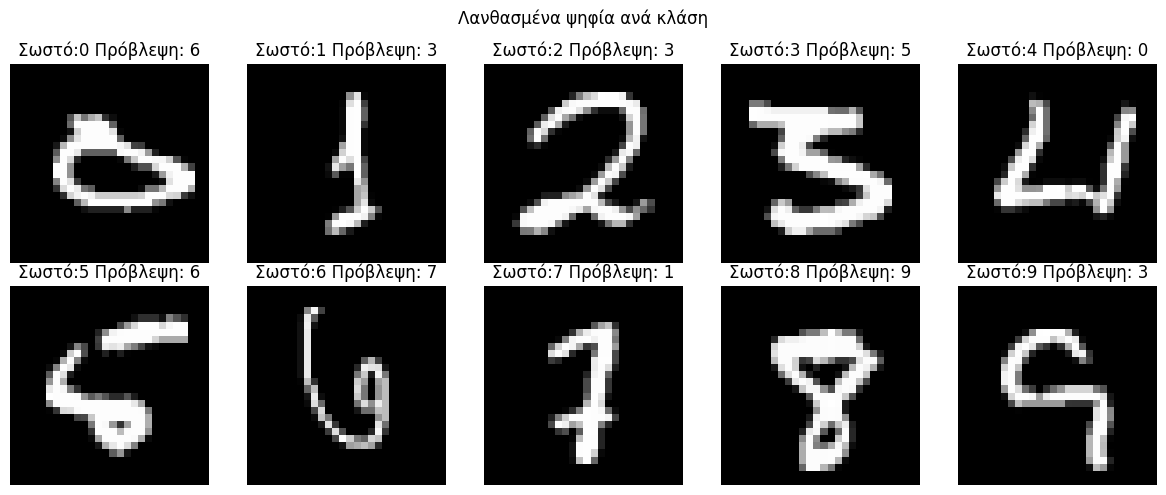

In [18]:
m=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(512,activation='relu'),

    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

m.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),loss='categorical_crossentropy',     metrics=['accuracy'])
m.fit(x_train,y_train,epochs=20,validation_data=(x_test, y_test),verbose=0)
pred=np.argmax(m.predict(x_test), axis=1)
true=np.argmax(y_test.numpy(),      axis=1)
fig,axes=plt.subplots(2,5,figsize=(12,5))
axes=axes.flatten()
for cls in range(10):
    wrong = np.where((true==cls) & (pred !=true))[0]
    idx=wrong[0]
    axes[cls].imshow(x_test[idx].reshape(28,28),cmap='gray')


    axes[cls].set_title(f'Σωστό:{true[idx]} Πρόβλεψη: {pred[idx]}')
    axes[cls].axis('off')

plt.suptitle('Λανθασμένα ψηφία ανά κλάση')
plt.tight_layout()
plt.show()

## 3. Suggest & Implement workflow improvements, aside hyperparameter tuning. Can you think of any ways to increase the overall accuracy of the Neural Network?

Train Accuracy:96.73%
Val Accuracy:   97.12%


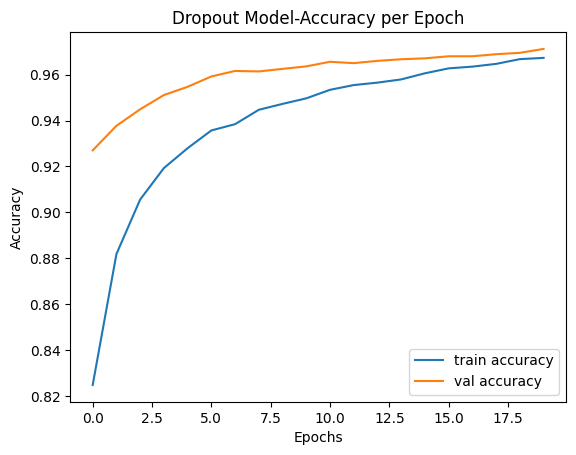

In [19]:
m2=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10,activation='softmax')
])

m2.compile(optimizer=tf.keras.optimizers.SGD(  learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])
h2=m2.fit(x_train, y_train, epochs=20,validation_data=(x_test, y_test),verbose=0)
train_acc=h2.history['accuracy'][-1]



val_acc=h2.history['val_accuracy'][-1]
print(f'Train Accuracy:{train_acc*100:.2f}%')
print(f'Val Accuracy:   {val_acc*100:.2f}%')

plt.plot(h2.history['accuracy'],label='train accuracy')
plt.plot(h2.history['val_accuracy'],label='val accuracy')
plt.title('Dropout Model-Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 4. Upload the exercise in your GitHub repository. Google Colab can instantly deploy this notebook into a Github repository.

## 5. Write a README file in your github repository, explaining:

1. Your workflow
2. The final model architecture
3. The selected hyperparameters
4. Include the requirements.txt file, which shows the python version, as well as the library versions.

In [ ]:
!pip show tensorflow